In [ ]:
!pip install pandas numpy matplotlib scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("churn_dataset.csv")

In [ ]:
df.head()

,Age,MonthlyCharges,ContractType,Churn
0,22,70,1,1
1,25,65,1,1
2,28,60,1,1
3,30,75,2,0
4,32,80,2,0


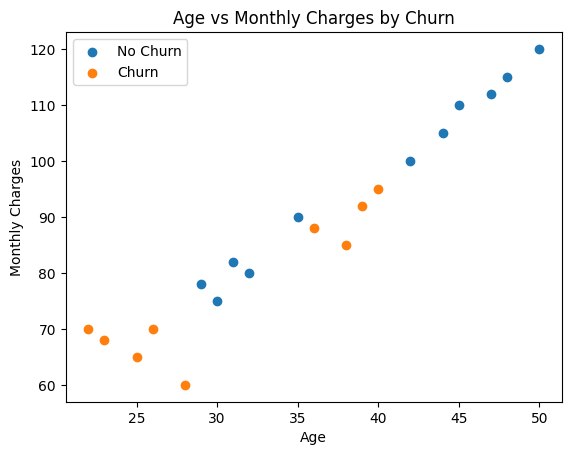

In [ ]:
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
plt.figure()
plt.scatter(churn_0["Age"], churn_0["MonthlyCharges"])
plt.scatter(churn_1["Age"], churn_1["MonthlyCharges"])

plt.xlabel("Age")
plt.ylabel("Monthly Charges")
plt.title("Age vs Monthly Charges by Churn")
plt.legend(["No Churn", "Churn"])
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[["Age", "MonthlyCharges", "ContractType"]]
y = df["Churn"]

model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
import numpy as np

new_customer = np.array([[33, 80, 1]])
probability = model.predict_proba(new_customer)

print("Probability of Churn:", probability[0][1])

Probability of Churn: 0.8344051269229709


C:\Users\suman\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
predictions = model.predict(X)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
"""" Why Logistic Regression is suitable for this dataset

Logistic regression is a good choice because our dataset has a binary outcome (for example, churn vs. no churn, yes vs. no). This model is designed exactly for situations where the target is categorical with two classes. It works by estimating the probability of an event happening, which makes the results easy to understand.

It is also suitable because the input features (like age, monthly charges, contract type) can be combined in a linear way to explain the outcome. Logistic regression gives us clear coefficients that show how each feature affects the chance of churn. This makes the model not only useful for prediction but also easy to interpret in simple terms.

In short, logistic regression is simple, efficient, and interpretable, which makes it a suitable model for this dataset. """

'" Why Logistic Regression is suitable for this dataset\n\nLogistic regression is a good choice because our dataset has a binary outcome (for example, churn vs. no churn, yes vs. no). This model is designed exactly for situations where the target is categorical with two classes. It works by estimating the probability of an event happening, which makes the results easy to understand.\n\nIt is also suitable because the input features (like age, monthly charges, contract type) can be combined in a linear way to explain the outcome. Logistic regression gives us clear coefficients that show how each feature affects the chance of churn. This makes the model not only useful for prediction but also easy to interpret in simple terms.\n\nIn short, logistic regression is simple, efficient, and interpretable, which makes it a suitable model for this dataset. '

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
df = pd.read_csv("loan_approval_dataset.csv")

In [ ]:
df.head()

,ApplicantIncome_k,CreditScore,LoanAmount_k,LoanApproved
0,50,700,200,1
1,30,650,100,0
2,80,720,250,1
3,60,680,150,1
4,45,600,120,0


In [ ]:
X = df[["ApplicantIncome_k", "CreditScore", "LoanAmount_k"]]
y = df["LoanApproved"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Accuracy: 0.83
Precision: 1.00
Recall: 0.80
F1-Score: 0.89


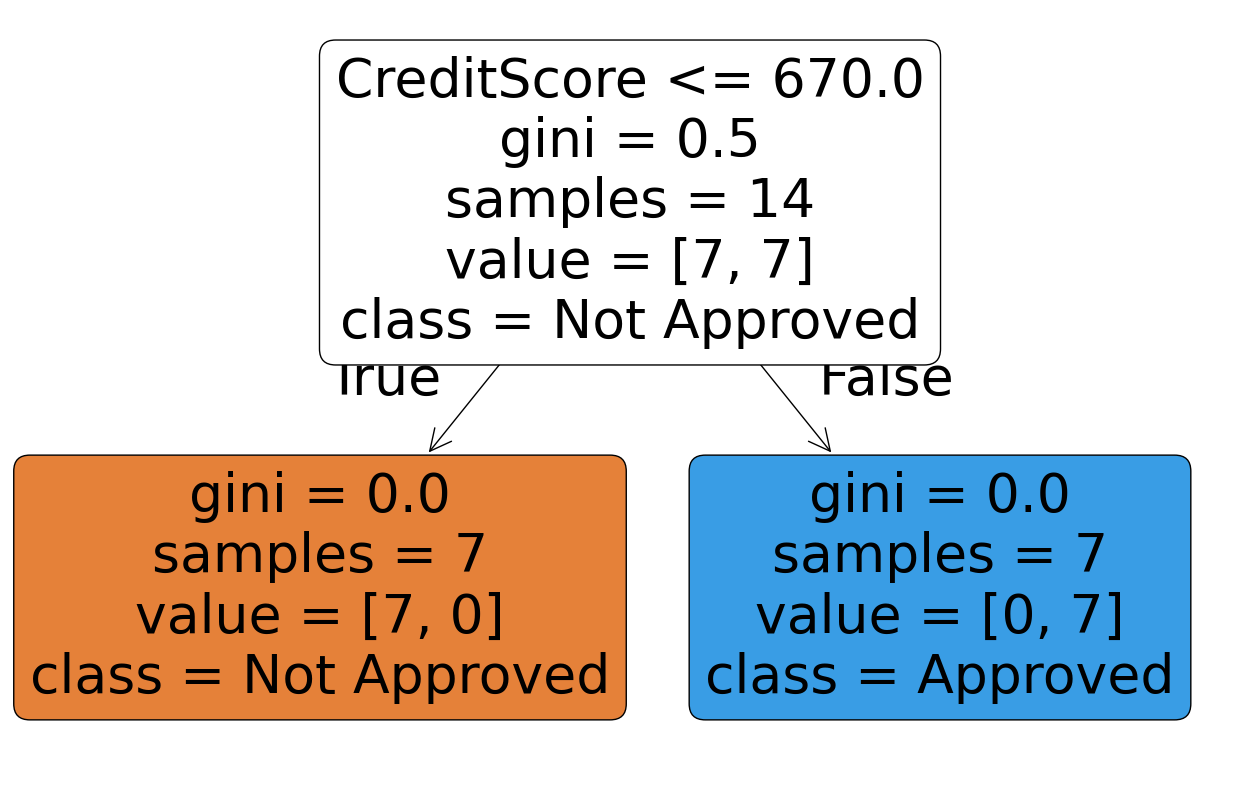

In [ ]:
plt.figure(figsize=(16,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True
)
plt.show()


In [ ]:
""" Discussion: When would a decision tree be preferred over logistic regression?

A decision tree is preferred when the relationship between features and the outcome is non-linear or too complex for a straight-line model. Unlike logistic regression, which assumes a linear relationship, decision trees can split the data into smaller groups and capture patterns more flexibly.

They are also useful when the dataset has mixed types of variables (numbers and categories) and when interpretability is important, because the tree shows clear rules like “if MonthlyCharges > 70 and ContractType = short, then churn = yes.” """"

SyntaxError: unterminated string literal (detected at line 5) (1471382583.py, line 5)